In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import umap

import oklab

# --- Constants ---
RANDOM_SEED = 42
OKLAB_L_MIN, OKLAB_L_MAX = 0.0, 1.0 # Oklab L is generally in [0, 1]
# Define normalization range for a and b. Adjust if needed based on data analysis.
# OKLAB_A_MIN, OKLAB_A_MAX = -0.5, 0.5
# OKLAB_B_MIN, OKLAB_B_MAX = -0.5, 0.5
# L component: Min=0.0000, Max=1.0000, Mean=0.5481, Std=0.2681
# A component: Min=-0.2322, Max=0.2762, Mean=0.0131, Std=0.0418
# B component: Min=-0.3116, Max=0.1985, Mean=0.0155, Std=0.0439
OKLAB_A_MIN, OKLAB_A_MAX = -0.25, 0.3333
OKLAB_B_MIN, OKLAB_B_MAX = -0.3333, 0.2
OKLAB_A_RANGE = OKLAB_A_MAX - OKLAB_A_MIN
OKLAB_B_RANGE = OKLAB_B_MAX - OKLAB_B_MIN

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
print(f"NumPy Version: {np.__version__}")
print(f"Polars Version: {pl.__version__}")
print(f"UMAP Version: {umap.__version__}")

NumPy Version: 2.4.2
Polars Version: 1.38.1
UMAP Version: 0.5.11


In [4]:
df = pl.read_parquet('../dataset/dataset.parquet')
df

color_0,color_1,color_2,color_3,source
str,str,str,str,str
"""#131314""","""#d0cfbc""","""#5f5957""","""#a69583""","""albums1"""
"""#86566f""","""#f1e1f1""","""#c89fa5""","""#2f2b37""","""albums1"""
"""#2c2c2c""","""#bbbbbb""","""#010101""","""#626262""","""albums1"""
"""#a2cf62""","""#4c2117""","""#615f43""","""#83a15b""","""albums1"""
"""#e3cf9e""","""#393a38""","""#fcfbf3""","""#c2a45c""","""albums1"""
…,…,…,…,…
"""#1eb9c2""","""#000100""","""#6f28a0""","""#c22cad""","""library2"""
"""#fef4e1""","""#0b1743""","""#fe6a6a""","""#c80136""","""library2"""
"""#312027""","""#e69e4e""","""#734046""","""#a15243""","""library2"""


In [5]:
color_cols = [f'color_{i}' for i in range(4)]
df = df.select(color_cols)

# Function to parse hex string to RGB tuple
def hex_to_rgb(hex_str):
    if not isinstance(hex_str, str) or not hex_str.startswith('#') or len(hex_str) != 7:
        return None # Invalid format
    hex_str = hex_str.lstrip('#')
    try:
        return tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4))
    except ValueError:
        return None # Invalid hex characters

# Parse hex codes in each color column
rgb_palettes_list = []
for row in df.iter_rows(named=True):
    palette = []
    valid_palette = True
    for col in color_cols:
        rgb = hex_to_rgb(row[col])
        if rgb is None:
            valid_palette = False
            break
        palette.append(rgb)
    if valid_palette:
        rgb_palettes_list.append(palette)

# Convert list of lists of tuples to a NumPy array (N, 4, 3)
rgb_palettes_np = np.array(rgb_palettes_list, dtype=np.uint8)

Converted palettes to normalized Oklab.
Normalized Oklab array shape: (102820, 4, 3)
Data type: float64
Example Normalized Oklab palette (first one):
[[ 0.18717006  0.00202589 -1.2902044 ]
 [ 0.85010462  0.02567408  1.82426438]
 [ 0.46899853  0.008414    0.68236354]
 [ 0.67980102  0.03266411  1.20040703]]

Visualizing first 20 palettes after Oklab -> RGB conversion (verification):


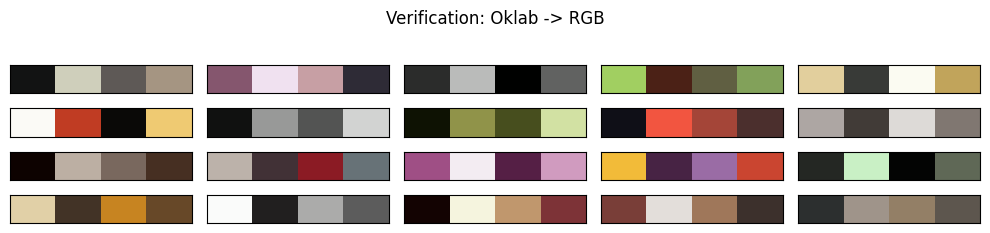

In [7]:
def convert_rgb_to_norm_oklab(rgb_array_uint8):
    """Converts an array of sRGB palettes (0-255, uint8) to normalized Oklab (0-1)."""
    return oklab.np_srgb_to_oklch(rgb_array_uint8)


def convert_norm_oklab_to_rgb(norm_oklab_array_float32):
    """Converts an array of normalized Oklab palettes (0-1) back to sRGB (0-255, uint8)."""

    return oklab.np_oklch_to_srgb(norm_oklab_array_float32)

# --- Perform Conversion and Create Tensors ---
# Convert RGB data to Normalized Oklab
oklab_palettes_norm_np = convert_rgb_to_norm_oklab(rgb_palettes_np)
print(f"Converted palettes to normalized Oklab.")
print(f"Normalized Oklab array shape: {oklab_palettes_norm_np.shape}")
print(f"Data type: {oklab_palettes_norm_np.dtype}")
print("Example Normalized Oklab palette (first one):")
print(oklab_palettes_norm_np[0])

# --- Verify Conversion (Convert back to RGB and visualize) ---
rgb_palettes_verify_np = convert_norm_oklab_to_rgb(oklab_palettes_norm_np[:20]) # Verify first 20
# Convert back to list of lists for visualization function
rgb_palettes_verify_list = [list(map(tuple, palette)) for palette in rgb_palettes_verify_np]

def visualize_palettes(palettes, title="Palettes", n_cols=5):
    """Visualizes a list of palettes (list of lists/tuples of RGB int values)."""
    # (Using a simplified version from the original notebook for brevity)
    n_palettes = len(palettes)
    if n_palettes == 0:
        print(f"No palettes to display for {title}")
        return
    n_rows = (n_palettes + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 0.6), squeeze=False)
    axes = axes.flatten()
    for i, palette in enumerate(palettes):
        try:
            normalized_palette = [(r/255.0, g/255.0, b/255.0) for r, g, b in palette]
            cmap = mcolors.ListedColormap(normalized_palette)
            axes[i].imshow([list(range(len(palette)))], cmap=cmap, aspect='auto')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            # axes[i].set_title(f"P {i+1}", fontsize=8, pad=1) # Optional title
        except Exception as e:
                axes[i].set_title(f"Error", fontsize=8)
                axes[i].set_axis_off()
    for j in range(n_palettes, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\nVisualizing first 20 palettes after Oklab -> RGB conversion (verification):")
visualize_palettes(rgb_palettes_verify_list, title="Verification: Oklab -> RGB", n_cols=5)


In [ ]:
# Reshape data for UMAP: (N, 4, 3) -> (N, 12)
n_palettes = oklab_palettes_norm_np.shape[0]
palette_dim = oklab_palettes_norm_np.shape[1] * oklab_palettes_norm_np.shape[2] # 4 * 3 = 12
palettes_12d = oklab_palettes_norm_np.reshape(n_palettes, palette_dim)

# keep only the first color (3d)
palettes_12d = palettes_12d[:, :3]

print(f"Reshaped data for UMAP: {palettes_12d.shape}")

# Initialize and fit UMAP
print("Running UMAP...")
umap_model = umap.UMAP(
    n_components=2,          # Reduce to 2 dimensions for visualization
    n_neighbors=15,          # Default, controls local vs global structure balance
    min_dist=0.1,            # Default, controls how tightly points are packed
    #metric='euclidean',      # Default distance metric
    #random_state=RANDOM_SEED # For reproducibility
)
palettes_2d = umap_model.fit_transform(palettes_12d)
print("UMAP fitting complete.")
print(f"UMAP embedding shape: {palettes_2d.shape}")

Reshaped data for UMAP: (102820, 3)
Running UMAP...


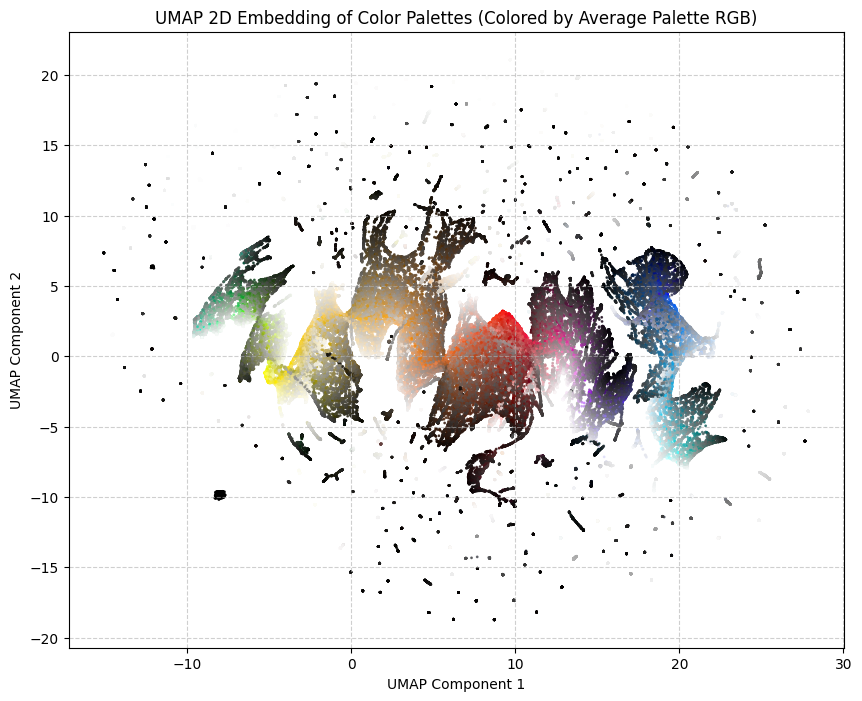

In [ ]:
# Calculate average RGB color for each palette for coloring the plot points
# rgb_palettes_np has shape (N, 4, 3) with values in [0, 255]
#plot_rgb_colors = np.mean(rgb_palettes_np, axis=1)
plot_rgb_colors = rgb_palettes_np[:,0, :]
# Normalize to [0, 1] for matplotlib
average_rgb_colors_norm = plot_rgb_colors / 255.0

plt.figure(figsize=(10, 8))
plt.scatter(
    palettes_2d[:, 0],
    palettes_2d[:, 1],
    c=average_rgb_colors_norm, # Use average palette color
    s=1,
    alpha=0.8 # Adjusted alpha slightly for better visibility with colors
)
plt.title('UMAP 2D Embedding of Color Palettes (Colored by Average Palette RGB)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

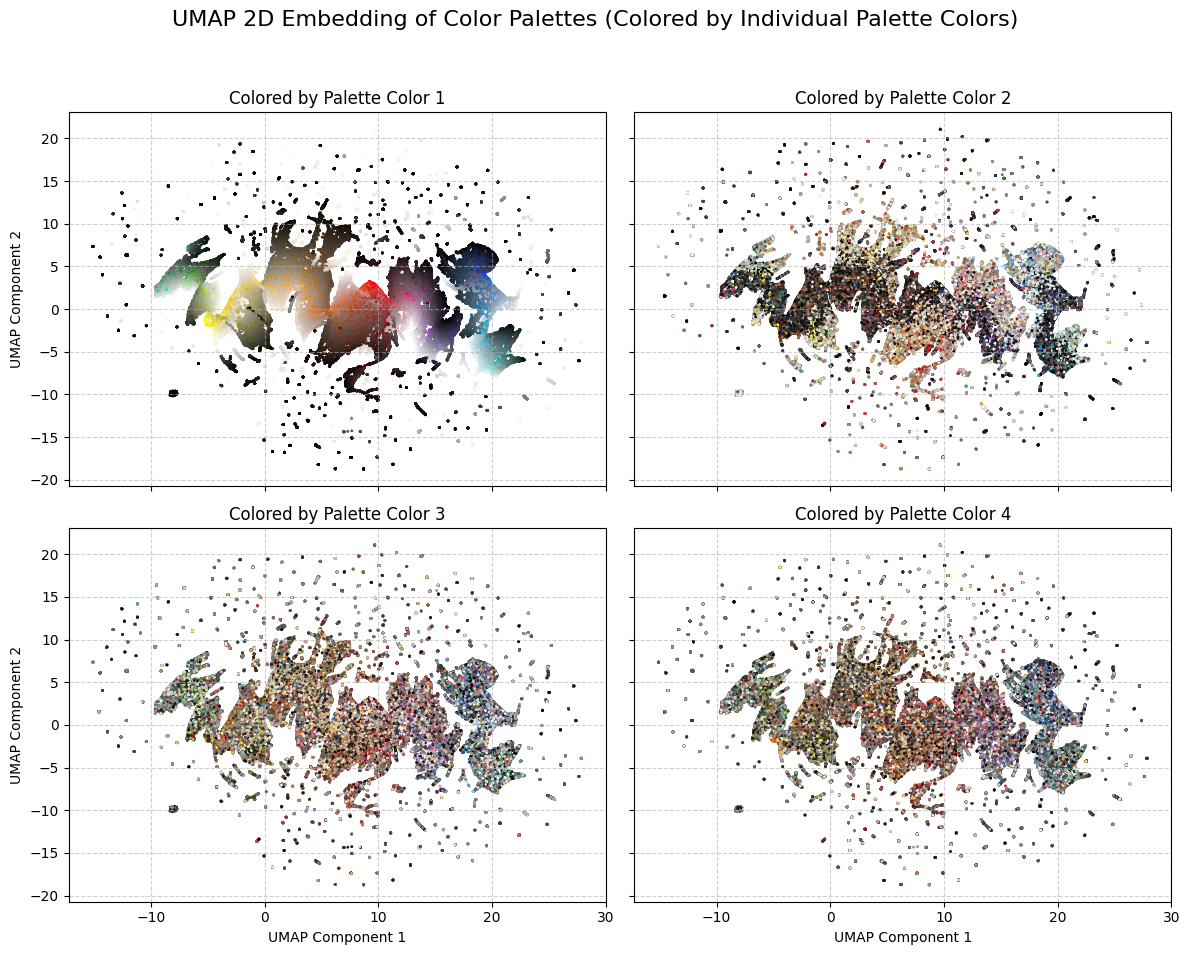

In [ ]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten() # Flatten the 2x2 array for easy iteration

# Titles for each subplot
titles = [
    'Colored by Palette Color 1',
    'Colored by Palette Color 2',
    'Colored by Palette Color 3',
    'Colored by Palette Color 4'
]

# Plot UMAP embedding colored by each palette color index
for i in range(4):
    # Select the i-th RGB color for each palette
    plot_rgb_colors = rgb_palettes_np[:, i, :] # Shape (N, 3)
    # Normalize to [0, 1] for matplotlib
    plot_rgb_colors_norm = plot_rgb_colors / 255.0

    ax = axes[i]
    scatter = ax.scatter(
        palettes_2d[:, 0],
        palettes_2d[:, 1],
        c=plot_rgb_colors_norm,
        s=1,
        alpha=1
    )
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add labels only to the outer plots
    if i >= 2: # Bottom row
        ax.set_xlabel('UMAP Component 1')
    if i % 2 == 0: # Left column
        ax.set_ylabel('UMAP Component 2')

# Add a main title for the figure
fig.suptitle('UMAP 2D Embedding of Color Palettes (Colored by Individual Palette Colors)', fontsize=16)

# Adjust layout to prevent titles/labels overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
plt.show()
